# 03 — Visualizations

This notebook produces all charts for the final presentation.
Charts 1–5 explore raw data distributions and patterns.
Charts 6–8 directly visualize key findings from `01_mychart.ipynb` and `02_distance.ipynb`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import *
from src.plot_utils import set_style, save_fig

set_style()

ModuleNotFoundError: No module named 'pandas'

**Chart 1: MyChart activation rate by age group (10-year bins)**
What we include:
Include only real status: Activated, Inactive, Pending Activation, Patient Declined, Activation Code Generated but Disabled, and Non Standard MyChart Status.

We exclude *Unspecified because it means the MyChart status is unknown.This would lead to lower activation rate because number of *Unspecified response is huge

Calculation for activation rate:
Activated = 1, every other known status = 0.
Then take the average within each 10-year age group.

Saved: mychart_activation_by_age_group


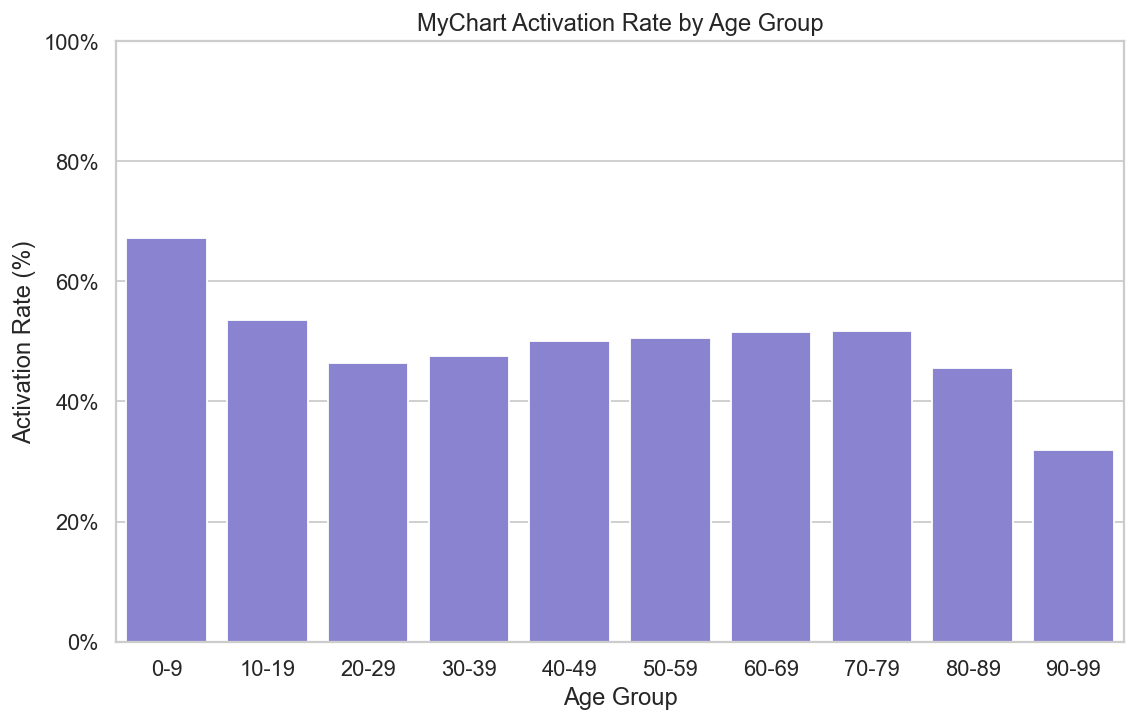

In [ ]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))

sns.barplot(
    data=activation_df,
    x="age_group",
    y="activation_rate",
    color="#7F77DD"
)

plt.title("MyChart Activation Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Activation Rate (%)")

# Format y-axis as percentage and set limits
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1) 

save_fig(plt.gcf(), "mychart_activation_by_age_group")
plt.show()

**Chart 2: ED Rate: App Users vs Non-App Users**
Each encounter represents a single visit, with IsEdVisit indicating whether the visit was an emergency (1) or not (0). The ED rate is calculated as the proportion of encounters that are ED visits within each group.

C:\Users\Owner\AppData\Local\Temp\ipykernel_32520\1644997558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: ed_rate_app_vs_nonapp


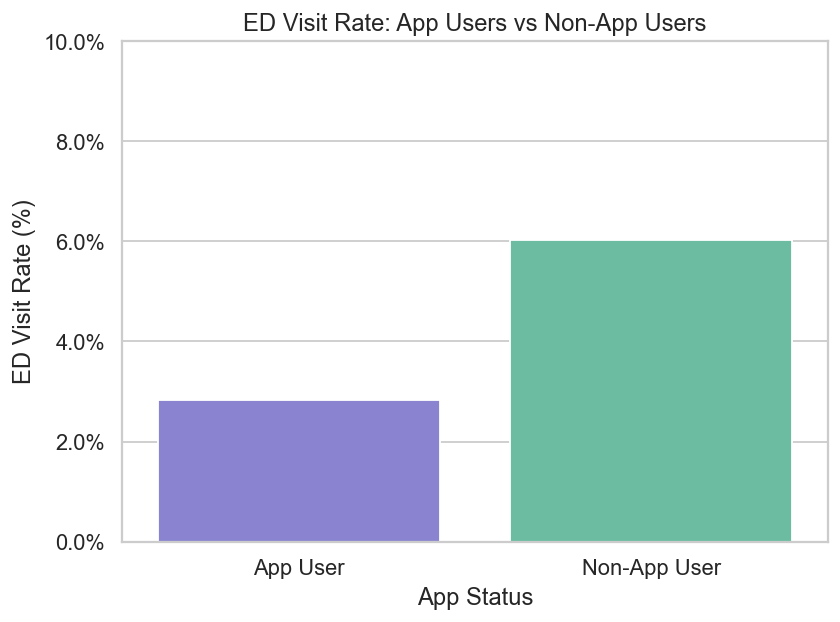

In [ ]:
import matplotlib.ticker as mtick

plt.figure(figsize=(7, 5))

sns.barplot(
    data=ed_rate_df,
    x="app_status",
    y="ed_rate",
    palette=["#7F77DD", "#5DCAA5"]
)

plt.title("ED Visit Rate: App Users vs Non-App Users")
plt.xlabel("App Status")
plt.ylabel("ED Visit Rate (%)")

# Format y-axis as percentage and set limits
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 0.1)

save_fig(plt.gcf(), "ed_rate_app_vs_nonapp")
plt.show()

**Chart 3a: Journey length distribution by app status**
Journey length of each patient here is calculated as date of last visit - date of first visit (duration, NOT number of visit)
We compare the duration of visits between two groups of patients: App Users ( "Activated" status on Mychart and Non-app Users (all other statuses))

C:\Users\Owner\AppData\Local\Temp\ipykernel_32520\1596447697.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  enc["Date"] = pd.to_datetime(enc["Date"], errors="coerce")


Saved: journey_length_distribution


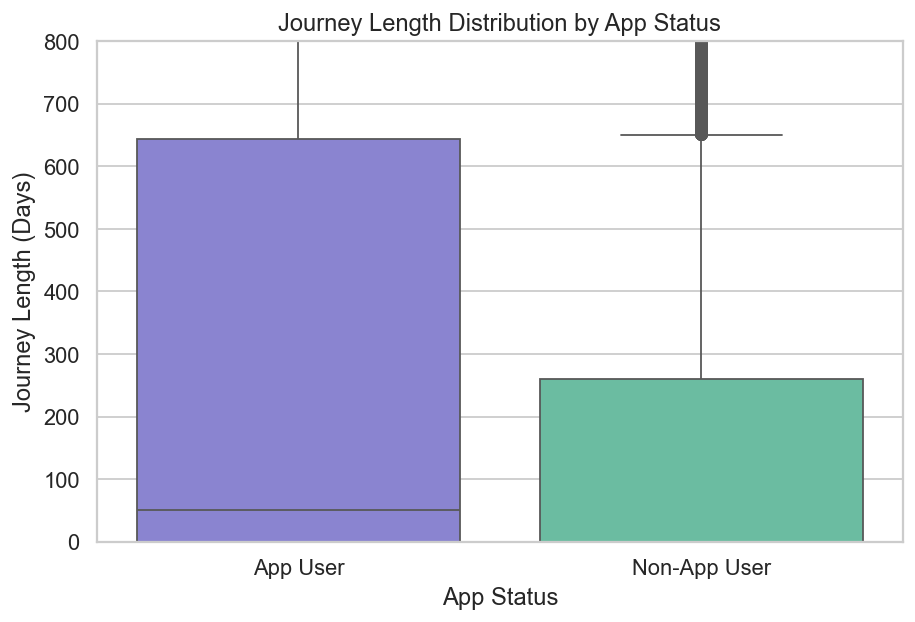

In [ ]:
# --- Journey Length Distribution by App Status ---
from src.data_loader import load_patients, load_encounters
# Load data
pat = load_patients()
enc = load_encounters(cols=["PatientDurableKey", "Date"], sample_frac=0.05)  # 5% sample for faster processing

# Convert Date column to datetime
enc["Date"] = pd.to_datetime(enc["Date"], errors="coerce")

# Remove invalid/missing dates
enc = enc.dropna(subset=["Date"])

# Compute journey length per patient:
# first visit ->  last visit
journey = (
    enc.groupby("PatientDurableKey")["Date"]
    .agg(first_visit="min", last_visit="max")
    .reset_index()
)

# Duration in days
journey["journey_length_days"] = (
    journey["last_visit"] - journey["first_visit"]
).dt.days

# Exclude unknown MyChart status
pat = pat[pat["MyChartStatus"] != "*Unspecified"].copy()

# Define app status
pat["app_status"] = np.where(
    pat["MyChartStatus"] == "Activated",
    "App User",
    "Non-App User"
)

# Merge journey with patient app status
journey = journey.merge(
    pat[["DurableKey", "app_status"]],
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="inner"
)

# Plot distribution (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    data=journey, x="app_status", y="journey_length_days",
    hue="app_status",
    palette={"App User": "#7F77DD", "Non-App User": "#5DCAA5"},
    legend=False
)

plt.title("Journey Length Distribution by App Status")
plt.xlabel("App Status")
plt.ylabel("Journey Length (Days)")
plt.ylim(0, 800)

save_fig(plt.gcf(), "journey_length_distribution")
plt.show()

**Chart 3b: Journey Length Distribution (KDE)**
Same data as Chart 3 but displayed as a kernel density estimate.
KDE is better suited here because journey length is heavily right-skewed —
most patients have short journeys but a long tail extends to 800+ days.
The shape difference between app and non-app users is more visible in this format.

Saved: journey_length_kde


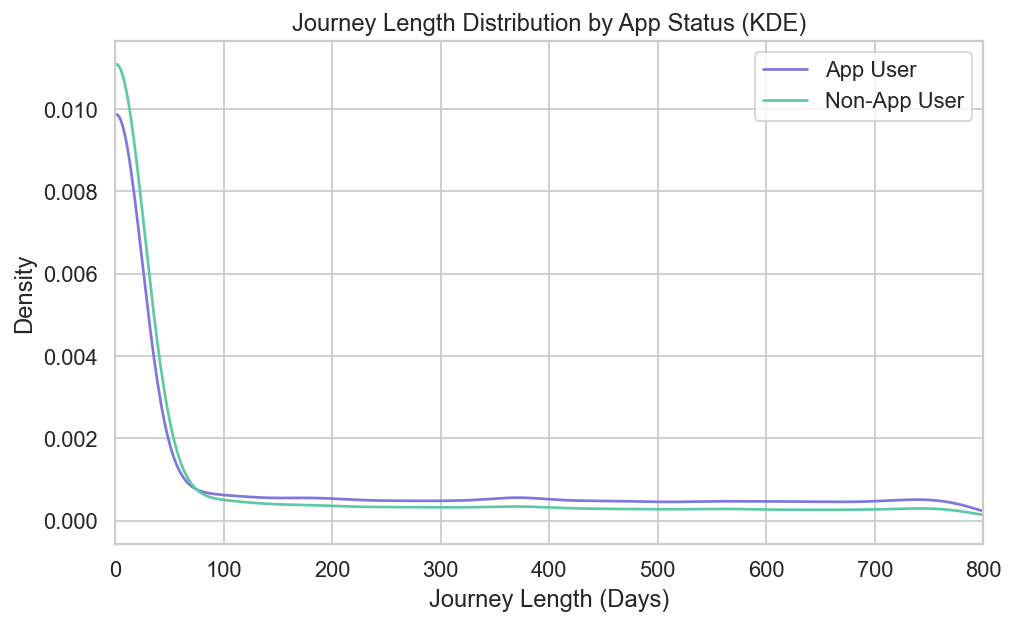

In [ ]:
# --- Journey Length Distribution by App Status (KDE) ---
# KDE shows the shape of the distribution more clearly than boxplot
# when data is heavily right-skewed

plt.figure(figsize=(8, 5))

for status, grp in journey[journey["journey_length_days"] < 800].groupby("app_status"):
    color = "#7F77DD" if status == "App User" else "#5DCAA5"
    grp["journey_length_days"].plot(kind="kde", label=status, color=color)

plt.title("Journey Length Distribution by App Status (KDE)")
plt.xlabel("Journey Length (Days)")
plt.xlim(0, 800)
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

save_fig(plt.gcf(), "journey_length_kde")
plt.show()

**Chart 4: Follow-up Gap Distribution by App Status**
Defined as the gap in days between consecutive visits for the same patient.
Distribution is compared between App users and Non-app users,
excluding patients with unspecified MyChart status.
Note: gap is capped at 365 days to focus on the core distribution.

C:\Users\Owner\AppData\Local\Temp\ipykernel_32520\264593485.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  enc["Date"] = pd.to_datetime(enc["Date"], errors="coerce")


Saved: followup_gap_distribution


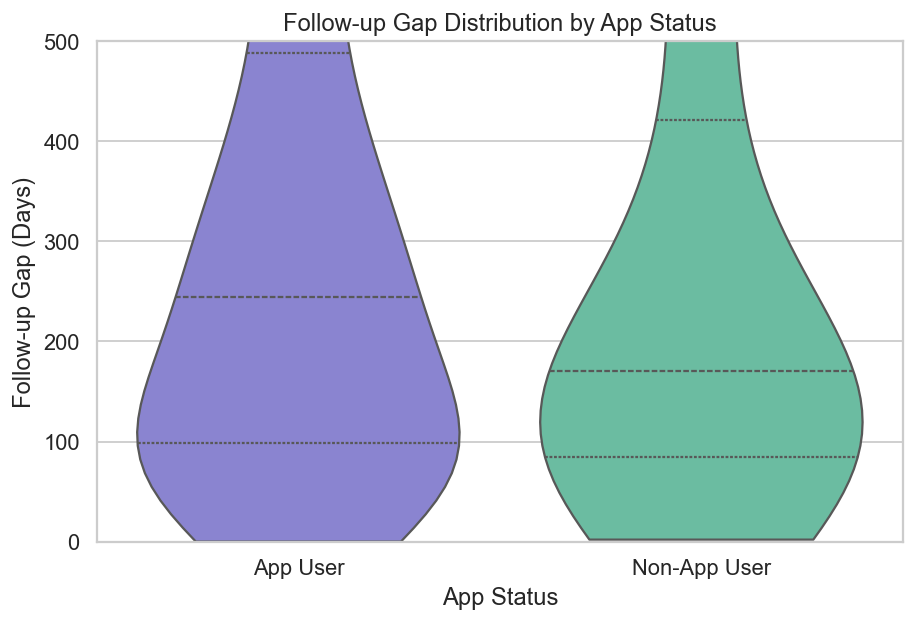

Gaps after Type filter: 963
Unique Type values in sample: <StringArray>
['Appointment', 'Follow-Up']
Length: 2, dtype: str


In [ ]:
# --- Follow-up Gap Distribution by App Status ---

from src.data_loader import load_patients, load_encounters

# Load data
pat = load_patients()
enc = load_encounters(cols=["PatientDurableKey", "Date", "Type"], sample_frac=0.05)  # 5% sample for faster processing

# Convert Date to datetime
enc["Date"] = pd.to_datetime(enc["Date"], errors="coerce")

# Keep only Appointment and Follow-Up visits
enc = enc[enc["Type"].isin(["Appointment", "Follow-Up"])].copy()

# Sort by patient and date
enc = enc.sort_values(["PatientDurableKey", "Date"])

# Get next visit type/date for each patient
enc["next_type"] = enc.groupby("PatientDurableKey")["Type"].shift(-1)
enc["next_date"] = enc.groupby("PatientDurableKey")["Date"].shift(-1)

# Keep only Appointment → Follow-Up pairs
gaps = enc[
    (enc["Type"] == "Appointment") &
    (enc["next_type"] == "Follow-Up")
].copy()

# Compute gap in days
gaps["followup_gap_days"] = (gaps["next_date"] - gaps["Date"]).dt.days

# Remove invalid (negative) gaps
gaps = gaps[gaps["followup_gap_days"] >= 0]

# Exclude unknown MyChart status
pat = pat[pat["MyChartStatus"] != "*Unspecified"].copy()

# Define app status
pat["app_status"] = np.where(
    pat["MyChartStatus"] == "Activated",
    "App User",
    "Non-App User"
)

# Merge with patient info
gaps = gaps.merge(
    pat[["DurableKey", "app_status"]],
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="inner"
)

# Plot violin distribution
plt.figure(figsize=(8,5))
sns.violinplot(
    data=gaps,
    x="app_status",
    y="followup_gap_days",
    hue="app_status",
    palette={"App User": "#7F77DD", "Non-App User": "#5DCAA5"},
    inner="quartile",
    cut=0,
    legend=False
)

plt.title("Follow-up Gap Distribution by App Status")
plt.xlabel("App Status")
plt.ylabel("Follow-up Gap (Days)")
plt.ylim(0, 500)

save_fig(plt.gcf(), "followup_gap_distribution")
plt.show()

print(f"Gaps after Type filter: {len(gaps)}")
print(f"Unique Type values in sample: {enc['Type'].unique()}")

**Chart 5: Distance vs ED Rate**
Each point represents a census block group (minimum 20 visits).
Point size reflects total visit volume from that block.
Patient coordinates are linked via `CensusBlockGroupFipsCode` → TIGER centroid (CENTLAT, CENTLON),
and distance is calculated using `haversine_km()` from `distance_utils.py`,
with Stormont Vail Health main campus (Topeka, KS) as the reference point.

The trend line is nearly flat, indicating that distance alone
does not strongly predict emergency utilization.
This supports our main finding: MyChart activation and transportation
hardship are stronger predictors of ED rate than geographic distance.

[attach_patient_coords] 613315 patients dropped (no geocode match) out of 947685
Saved: distance_vs_ed_rate


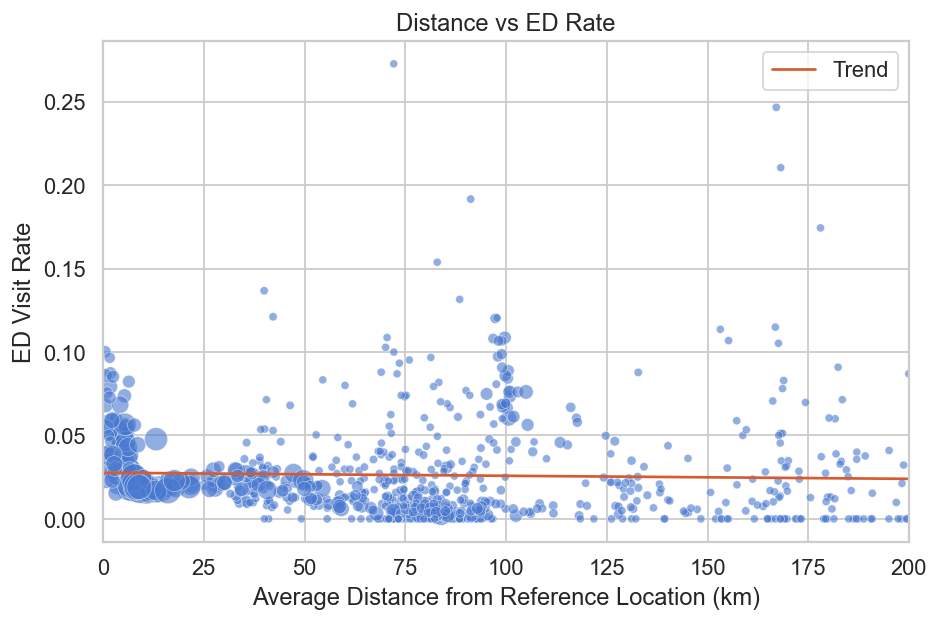

In [ ]:
# --- Distance vs ED Rate ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from src.data_loader import load_patients, load_encounters, load_tiger
from src.distance_utils import haversine_km, attach_patient_coords
from src.utils import save_fig  # assuming you have this

# --- Load needed datasets ---
pat = load_patients()
tiger = load_tiger()

enc = load_encounters(
    cols=["PatientDurableKey", "IsEdVisit"],
    sample_frac=1.0
)

# --- Attach patient coordinates ---
pat_geo = attach_patient_coords(pat, tiger)

# --- Reference location (hospital) ---
hospital_lat = 39.0558
hospital_lon = -95.6890

# --- Calculate distance ---
pat_geo["distance_km"] = haversine_km(
    pat_geo["pat_lat"],
    pat_geo["pat_lon"],
    hospital_lat,
    hospital_lon
)

# --- Keep relevant columns ---
pat_distance = pat_geo[
    ["DurableKey", "CensusBlockGroupFipsCode", "distance_km"]
].copy()

# --- Merge with encounters ---
enc_dist = enc.merge(
    pat_distance,
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="inner"
)

# --- Compute ED rate by census block group ---
distance_ed_df = (
    enc_dist
    .groupby("CensusBlockGroupFipsCode")
    .agg(
        avg_distance_km=("distance_km", "mean"),
        total_visits=("IsEdVisit", "count"),
        total_ed_visits=("IsEdVisit", "sum")
    )
    .reset_index()
)

distance_ed_df["ed_rate"] = (
    distance_ed_df["total_ed_visits"] / distance_ed_df["total_visits"]
)

# --- Remove small groups ---
distance_ed_df = distance_ed_df[distance_ed_df["total_visits"] >= 20].copy()

# --- Plot ---
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=distance_ed_df,
    x="avg_distance_km",
    y="ed_rate",
    size="total_visits",
    sizes=(20, 250),
    alpha=0.6,
    legend=False
)

plt.title("Distance vs ED Rate")
plt.xlabel("Average Distance from Reference Location (km)")
plt.ylabel("ED Visit Rate (%)")
plt.xlim(0, 200)

# --- Trend line ---
z = np.polyfit(distance_ed_df["avg_distance_km"], distance_ed_df["ed_rate"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(0, 200, 100)
plt.plot(x_line, p_line(x_line), color="#D85A30", linewidth=1.5, label="Trend")
plt.legend()

# --- Convert y-axis to percentage (OPTION 1) ---
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

# --- Save + show ---
save_fig(plt.gcf(), "distance_vs_ed_rate")
plt.show()

## Additional Charts: Key Findings from Analysis
The following charts directly visualize the core findings from
`01_mychart.ipynb` and `02_distance.ipynb`.

**Chart 6: ED Rate by App Status × Transportation Hardship**
The strongest finding from the analysis. Patients with both transport hardship
and no app access show the highest ED rates — nearly 13× higher than
app users without transport issues.

Saved: heatmap_app_transport_ed


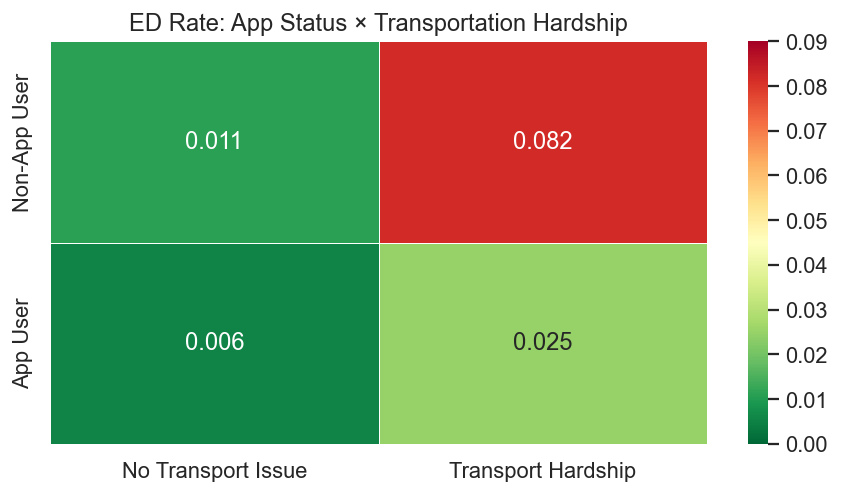

In [ ]:
# --- ED Rate Heatmap: App Status x Transportation Hardship ---
# Directly visualizes the strongest finding from 01_mychart.ipynb

journeys = pd.read_csv("../data/processed/journeys_final.csv")

heatmap_data = journeys.groupby(
    ["app_user", "transport_hardship"]
)["ed_rate"].mean().unstack()

heatmap_data.index = ["Non-App User", "App User"]
heatmap_data.columns = ["No Transport Issue", "Transport Hardship"]

plt.figure(figsize=(7, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    vmin=0, vmax=0.09
)
plt.title("ED Rate: App Status × Transportation Hardship")
plt.tight_layout()
save_fig(plt.gcf(), "heatmap_app_transport_ed")
plt.show()

**Chart 7: ED Rate by Distance Group and App Status**
From `02_distance.ipynb`. The app benefit is strongest for nearby patients —
near non-app users show the highest ED rate (0.023), while app activation
reduces this by 60% (0.009). For far patients, the app makes no difference.

Saved: ed_rate_distance_app_grouped


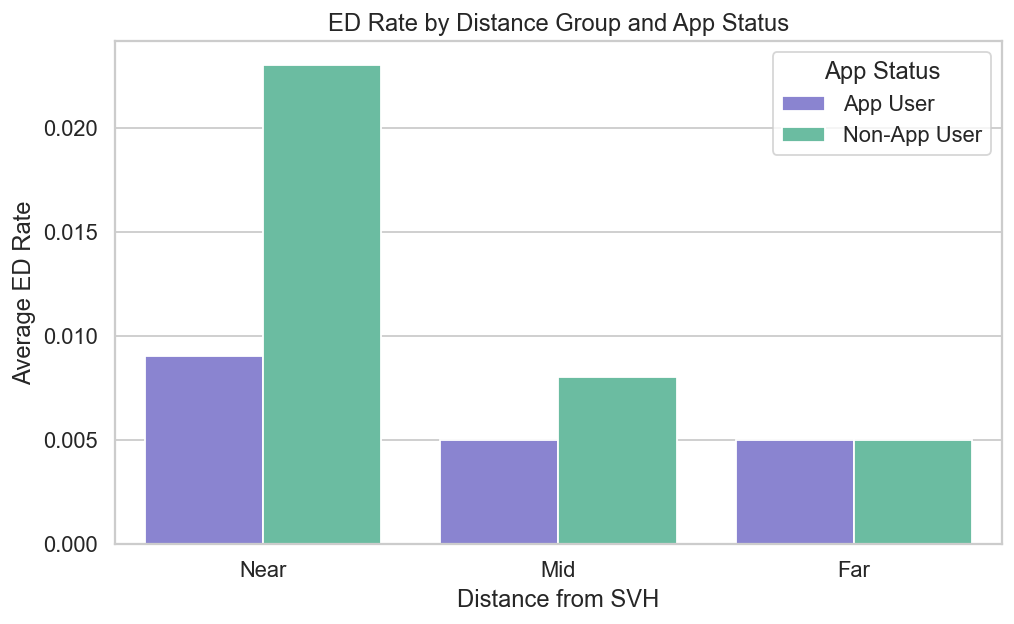

In [ ]:
# --- ED Rate by Distance Group x App Status ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# --- Data ---
cross_data = {
    "Near":  {"App User": 0.009, "Non-App User": 0.023},
    "Mid":   {"App User": 0.005, "Non-App User": 0.008},
    "Far":   {"App User": 0.005, "Non-App User": 0.005},
}

cross_df = pd.DataFrame(cross_data).T.reset_index()
cross_df = cross_df.melt(
    id_vars="index",
    var_name="App Status",
    value_name="ED Rate"
)
cross_df.columns = ["Distance Group", "App Status", "ED Rate"]

# --- Plot ---
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cross_df,
    x="Distance Group",
    y="ED Rate",
    hue="App Status",
    palette={"App User": "#7F77DD", "Non-App User": "#5DCAA5"}
)

plt.title("ED Rate by Distance Group and App Status")
plt.xlabel("Distance from SVH")
plt.ylabel("ED Visit Rate (%)")

# --- Convert y-axis to % (OPTION 1) ---
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

# --- Add value labels on top of bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1%}",  # correct % display
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )

# --- Optional: add headroom so labels don't get cut ---
plt.ylim(0, 0.11)

plt.tight_layout()
save_fig(plt.gcf(), "ed_rate_distance_app_grouped")
plt.show()

**Chart 8: Key Findings Summary Table**
A consolidated view of the core metrics across all analyses.
Intended for use as a reference slide in the final presentation.

Saved: summary_table


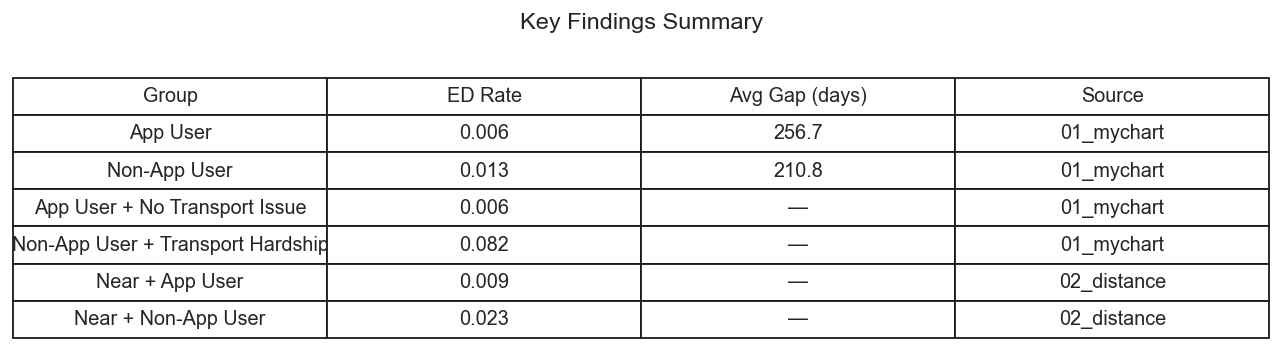

In [ ]:
# --- Summary Table of Key Findings ---
# Consolidates core metrics from 01_mychart and 02_distance

summary = {
    "Group": [
        "App User",
        "Non-App User",
        "App User + No Transport Issue",
        "Non-App User + Transport Hardship",
        "Near + App User",
        "Near + Non-App User"
    ],
    "ED Rate": [0.006, 0.013, 0.006, 0.082, 0.009, 0.023],
    "Avg Gap (days)": [256.7, 210.8, "—", "—", "—", "—"],
    "Source": [
        "01_mychart", "01_mychart",
        "01_mychart", "01_mychart",
        "02_distance", "02_distance"
    ]
}

summary_df = pd.DataFrame(summary)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
plt.title("Key Findings Summary", fontsize=13, pad=20)
plt.tight_layout()
save_fig(fig, "summary_table")
plt.show()